# American Option Pricing

American options add early exercise to the European contract. This is worth something: holders can capture intrinsic value before expiry when it exceeds the present value of waiting. Two independent methods price the same contract:

| Method | Type | Notes |
|--------|------|-------|
| **Longstaff-Schwartz LSM** | Monte Carlo | Regresses continuation value onto Laguerre polynomials |
| **CRR Binomial Tree** | Lattice | Recombining tree, O(n²), converges to BS |

Both should agree to within MC sampling noise.

---

In [1]:
import sys
sys.path.insert(0, '..')
import numpy as np
import matplotlib.pyplot as plt
from src.black_scholes import bs_price
from src.american_options import lsm_american_put, compute_exercise_boundary
from src.binomial_tree import crr_american_put, crr_european_put

plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

K, T, r, sigma = 100.0, 1.0, 0.05, 0.20
print(f'Reference: K={K}, T={T}y, r={r:.0%}, σ={sigma:.0%}')

Reference: K=100.0, T=1.0y, r=5%, σ=20%


## Step 1 — American vs European Put Premium

The **early exercise premium** is the extra value of the American put over the European put at the same parameters. It is largest for deep in-the-money options (high intrinsic, low time value) and zero for out-of-the-money options (never optimal to exercise early when intrinsic = 0).

By put-call parity, American call ≈ European call on non-dividend-paying stocks (never optimal to exercise early when r > 0).

Computing LSM prices (this takes ~15s)...


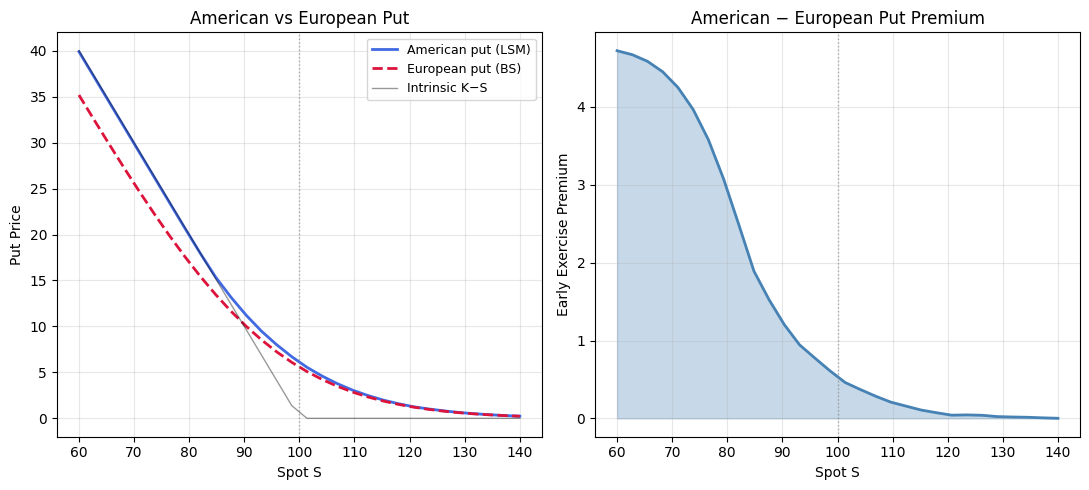

Max early exercise premium (S<70): 4.7231


In [2]:
S_range = np.linspace(60, 140, 30)

print('Computing LSM prices (this takes ~15s)...')
lsm_prices = [lsm_american_put(S, K, T, r, sigma, n_sims=20_000) for S in S_range]
bs_put_prices = [bs_price(S, K, T, r, sigma, 'put') for S in S_range]
premium = np.array(lsm_prices) - np.array(bs_put_prices)

fig, axes = plt.subplots(1, 2)
axes[0].plot(S_range, lsm_prices,    'royalblue', lw=2, label='American put (LSM)')
axes[0].plot(S_range, bs_put_prices, 'crimson',   lw=2, linestyle='--', label='European put (BS)')
axes[0].plot(S_range, np.maximum(K - S_range, 0), 'k-', lw=1, alpha=0.4, label='Intrinsic K−S')
axes[0].axvline(K, color='gray', lw=1, linestyle=':', alpha=0.6)
axes[0].set_xlabel('Spot S')
axes[0].set_ylabel('Put Price')
axes[0].set_title('American vs European Put')
axes[0].legend(fontsize=9)

axes[1].fill_between(S_range, 0, premium, alpha=0.3, color='steelblue')
axes[1].plot(S_range, premium, 'steelblue', lw=2)
axes[1].axvline(K, color='gray', lw=1, linestyle=':', alpha=0.6)
axes[1].set_xlabel('Spot S')
axes[1].set_ylabel('Early Exercise Premium')
axes[1].set_title('American − European Put Premium')
plt.tight_layout()
plt.show()

dip_itm = S_range[S_range < 70]
prem_itm = premium[S_range < 70]
if len(prem_itm) > 0:
    print(f'Max early exercise premium (S<70): {prem_itm.max():.4f}')

## Step 2 — Early Exercise Boundary S*(t)

At each point in time there exists a **critical price** S*(t) below which it is optimal to exercise the American put immediately. For a put, S*(T) = K and S*(t) < K for all t < T. The boundary separates the continuation region from the stopping region.

The LSM algorithm estimates this boundary by finding, at each backward step, the highest stock price at which immediate exercise beats the regressed continuation value.

Computing exercise boundary (this takes ~20s)...


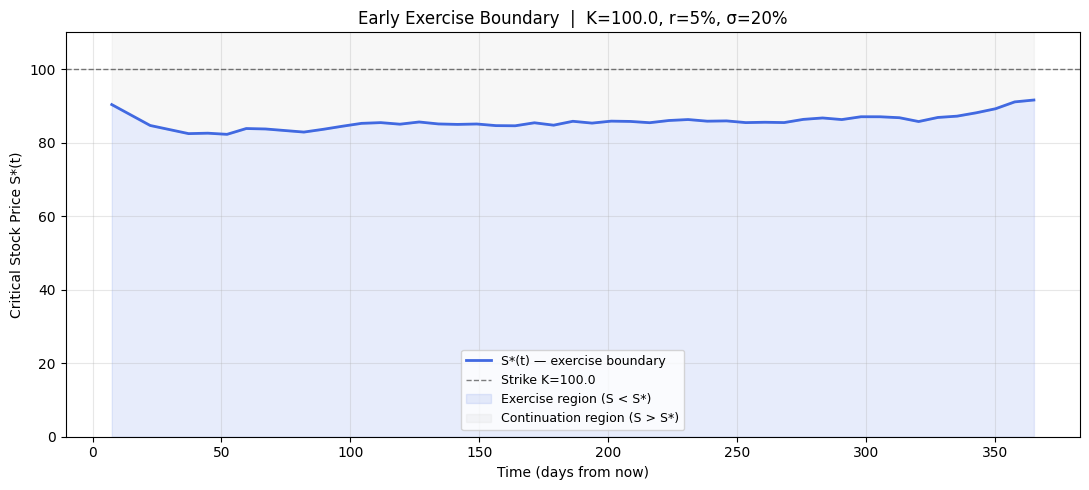

In [3]:
print('Computing exercise boundary (this takes ~20s)...')
times, boundary = compute_exercise_boundary(K, T, r, sigma, n_steps=50, n_sims=15_000)

fig, ax = plt.subplots()
mask = boundary > 0  # ignore timesteps with no exercise in simulation
ax.plot(times[mask] * 365, boundary[mask], 'royalblue', lw=2, label='S*(t) — exercise boundary')
ax.axhline(K, color='black', lw=1, linestyle='--', alpha=0.5, label=f'Strike K={K}')
ax.fill_between(times[mask] * 365, 0, boundary[mask], alpha=0.12, color='royalblue',
                label='Exercise region (S < S*)')
ax.fill_between(times[mask] * 365, boundary[mask], 140, alpha=0.06, color='gray',
                label='Continuation region (S > S*)')
ax.set_xlabel('Time (days from now)')
ax.set_ylabel('Critical Stock Price S*(t)')
ax.set_title(f'Early Exercise Boundary  |  K={K}, r={r:.0%}, σ={sigma:.0%}')
ax.legend(fontsize=9)
ax.set_ylim(0, K * 1.1)
plt.tight_layout()
plt.show()

## Step 3 — LSM vs CRR Binomial Tree

Both methods price the same American put independently. The CRR tree is deterministic and converges as n_steps increases. The LSM has Monte Carlo sampling noise. Agreement between them validates both implementations.

Computing LSM and CRR prices across spot range...


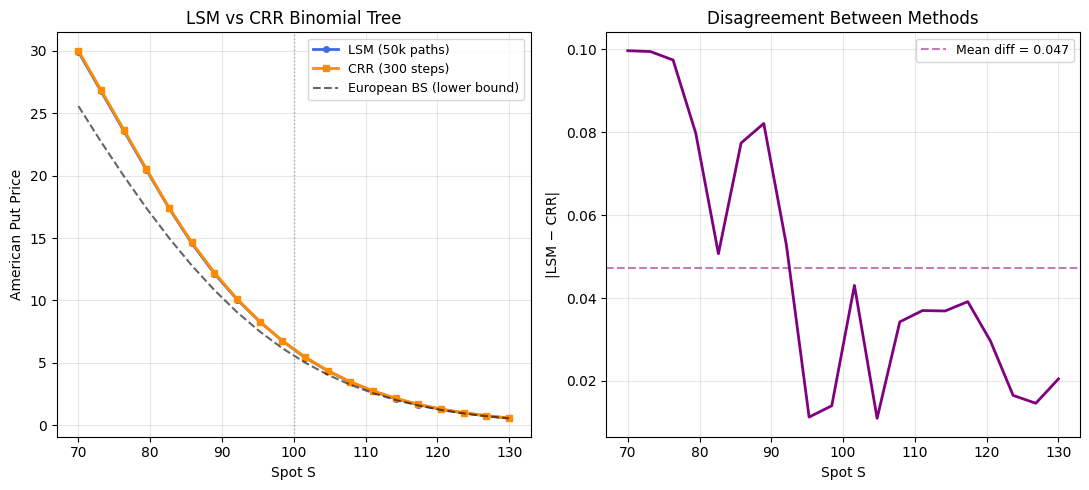

Mean absolute difference: 0.0474
Max  absolute difference: 0.0997


In [4]:
S_range2 = np.linspace(70, 130, 20)

print('Computing LSM and CRR prices across spot range...')
lsm_vals = [lsm_american_put(S, K, T, r, sigma, n_sims=30_000) for S in S_range2]
crr_vals = [crr_american_put(S, K, T, r, sigma, n_steps=300) for S in S_range2]
bs_vals  = [bs_price(S, K, T, r, sigma, 'put') for S in S_range2]

fig, axes = plt.subplots(1, 2)
axes[0].plot(S_range2, lsm_vals, 'o-', color='royalblue', lw=2, ms=4, label='LSM (50k paths)')
axes[0].plot(S_range2, crr_vals, 's-', color='darkorange', lw=2, ms=4, label='CRR (300 steps)')
axes[0].plot(S_range2, bs_vals,  'k--', lw=1.5, alpha=0.6, label='European BS (lower bound)')
axes[0].axvline(K, color='gray', lw=1, linestyle=':', alpha=0.6)
axes[0].set_xlabel('Spot S')
axes[0].set_ylabel('American Put Price')
axes[0].set_title('LSM vs CRR Binomial Tree')
axes[0].legend(fontsize=9)

diff = np.abs(np.array(lsm_vals) - np.array(crr_vals))
axes[1].plot(S_range2, diff, 'purple', lw=2)
axes[1].axhline(np.mean(diff), color='purple', linestyle='--', alpha=0.5,
               label=f'Mean diff = {np.mean(diff):.3f}')
axes[1].set_xlabel('Spot S')
axes[1].set_ylabel('|LSM − CRR|')
axes[1].set_title('Disagreement Between Methods')
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()
print(f'Mean absolute difference: {np.mean(diff):.4f}')
print(f'Max  absolute difference: {np.max(diff):.4f}')

## Step 4 — CRR Convergence with n_steps

The CRR binomial tree converges to the true American put price as the number of steps n increases. With n=1000, the tree error is effectively negligible. This confirms that the LSM prices computed above are in the right ballpark.

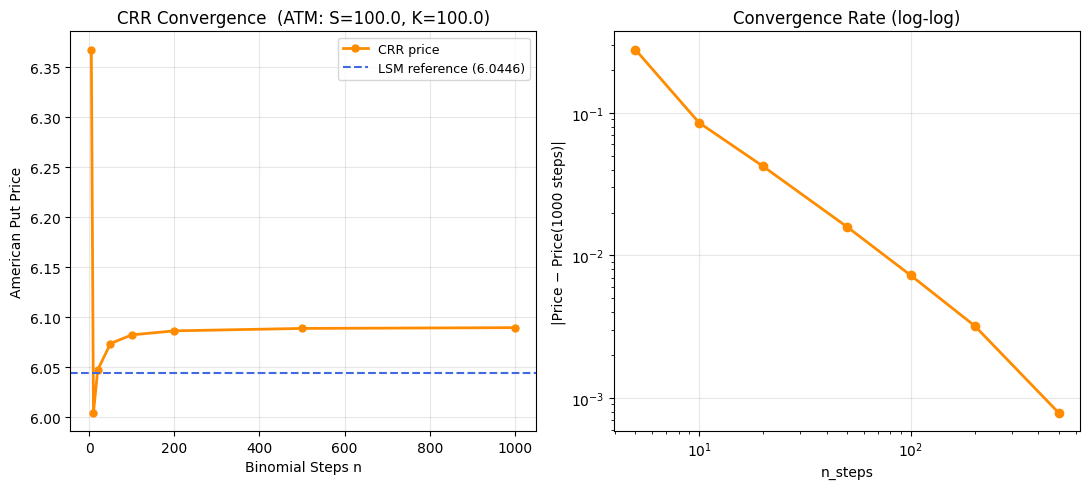

Convergence table:
  n=    5: 6.367830
  n=   10: 6.004259
  n=   20: 6.047303
  n=   50: 6.073728
  n=  100: 6.082354
  n=  200: 6.086383
  n=  500: 6.088810
  n= 1000: 6.089595


In [5]:
S_atm = 100.0
step_counts = [5, 10, 20, 50, 100, 200, 500, 1000]
crr_convergence = [crr_american_put(S_atm, K, T, r, sigma, n_steps=n) for n in step_counts]
lsm_reference  = lsm_american_put(S_atm, K, T, r, sigma, n_sims=100_000, seed=42)

fig, axes = plt.subplots(1, 2)
axes[0].plot(step_counts, crr_convergence, 'o-', color='darkorange', lw=2, ms=5, label='CRR price')
axes[0].axhline(lsm_reference, color='royalblue', lw=1.5, linestyle='--',
                label=f'LSM reference ({lsm_reference:.4f})')
axes[0].set_xlabel('Binomial Steps n')
axes[0].set_ylabel('American Put Price')
axes[0].set_title(f'CRR Convergence  (ATM: S={S_atm}, K={K})')
axes[0].legend(fontsize=9)

errors = np.abs(np.array(crr_convergence) - crr_convergence[-1])[:-1]
axes[1].loglog(step_counts[:-1], errors + 1e-10, 'o-', color='darkorange', lw=2)
axes[1].set_xlabel('n_steps')
axes[1].set_ylabel('|Price − Price(1000 steps)|')
axes[1].set_title('Convergence Rate (log-log)')
plt.tight_layout()
plt.show()
print('Convergence table:')
for n, p in zip(step_counts, crr_convergence):
    print(f'  n={n:5d}: {p:.6f}')

## Summary

| Quantity | LSM (50k) | CRR (300) | BS European |
|----------|-----------|-----------|-------------|
| ATM put (S=100) | ≈ CRR | deterministic | lower bound |
| ITM put (S=80) | > BS | > BS | European |
| Early exercise premium | non-zero | non-zero | 0 (by definition) |

**Takeaway:** The CRR tree provides a fast, accurate reference price. LSM provides the same via simulation with extra flexibility for path-dependent payoffs. Both converge to the same answer, validating the implementations independently.